# Modeling

This notebook contains code for building the baseline and two improvement models. The baseline is a logistic regression model, the first improvement is a standard CNN, and the final improvement is an encoder-decoder CNN model (U-Net Style Architecture).

## Imports

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, Input, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import Sequence

from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, jaccard_score
from sklearn.metrics import precision_recall_curve

## Connecting to Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Uploading the Data

This section uploads the data and ensures it has the proper shapes.

In [3]:
# Declare data path
DATA_PATH = "/content/drive/MyDrive/wildfire-prediction-data/processed-data/"

In [4]:
# Declare input and output features again
INPUT_FEATURES = [
    'tmmn', 'tmmx', 'th', 'vs', 'pr', 'sph',
    'pdsi', 'NDVI', 'erc', 'population', 'elevation', 'PrevFireMask'
]
OUTPUT_FEATURE = 'FireMask'
GRID_SIZE = 64

In [5]:
# Load the numpy arrays
X_train = np.load(DATA_PATH + 'X_train.npy')
Y_train = np.load(DATA_PATH + 'Y_train.npy')
X_val   = np.load(DATA_PATH + 'X_val.npy')
Y_val   = np.load(DATA_PATH + 'Y_val.npy')
X_test  = np.load(DATA_PATH + 'X_test.npy')
Y_test  = np.load(DATA_PATH + 'Y_test.npy')

In [6]:
# Print out shapes of each array
for name, arr in [('X_train', X_train), ('Y_train', Y_train),
                  ('X_val', X_val), ('Y_val', Y_val),
                  ('X_test', X_test), ('Y_test', Y_test)]:
    print(f"{name}: shape={arr.shape}, dtype={arr.dtype}, "
          f"min={np.nanmin(arr):.3f}, max={np.nanmax(arr):.3f}")

X_train: shape=(14979, 64, 64, 12), dtype=float32, min=-147.310, max=126.392
Y_train: shape=(14979, 64, 64), dtype=float32, min=-1.000, max=1.000
X_val: shape=(1877, 64, 64, 12), dtype=float32, min=-29.650, max=126.392
Y_val: shape=(1877, 64, 64), dtype=float32, min=-1.000, max=1.000
X_test: shape=(1689, 64, 64, 12), dtype=float32, min=-99.278, max=111.222
Y_test: shape=(1689, 64, 64), dtype=float32, min=-1.000, max=1.000


In [7]:
# Confirm feature ordering assumption holds (X should be N, 64, 64, 12)
assert X_train.shape[1:] == (GRID_SIZE, GRID_SIZE, len(INPUT_FEATURES)), \
    f"Unexpected X_train shape: {X_train.shape}"
assert Y_train.shape[1:] == (GRID_SIZE, GRID_SIZE), \
    f"Unexpected Y_train shape: {Y_train.shape}"

In [8]:
# Confirm Y label set matches expectation (-1, 0, 1)
print("\nUnique Y_train values:", np.unique(Y_train))
print("Unique Y_val values:", np.unique(Y_val))
print("Unique Y_test values:", np.unique(Y_test))


Unique Y_train values: [-1.  0.  1.]
Unique Y_val values: [-1.  0.  1.]
Unique Y_test values: [-1.  0.  1.]


In [9]:
# Build one combined target array per split
# combined[..., 0] = label (dummy 0 where invalid)
# combined[..., 1] = weight (0 = ignore, pos_weight = fire, 1 = no-fire)

def build_combined_target(Y, pos_weight):
    Y = Y.astype(np.float32)
    label = np.where(Y == -1, 0.0, Y).astype(np.float32)
    weight = np.where(Y == -1, 0.0, np.where(Y == 1, pos_weight, 1.0)).astype(np.float32)
    return np.stack([label, weight], axis=-1)  # shape (N, 64, 64, 2)

n_fire = (Y_train == 1).sum()
n_nofire = (Y_train == 0).sum()
pos_weight = n_nofire / n_fire
print(f"pos_weight: {pos_weight:.2f}")

target_train = build_combined_target(Y_train, pos_weight)
target_val   = build_combined_target(Y_val, pos_weight)
target_test  = build_combined_target(Y_test, pos_weight)

del Y_train, Y_val, Y_test
import gc; gc.collect()

print("target_train shape:", target_train.shape, "(expect N,64,64,2)")
!free -h

pos_weight: 90.02
target_train shape: (14979, 64, 64, 2) (expect N,64,64,2)
               total        used        free      shared  buff/cache   available
Mem:            12Gi       4.9Gi       1.3Gi       2.0Mi       6.4Gi       7.4Gi
Swap:             0B          0B          0B


## Building the Baseline Model

This baseline model is equivalent to a 1x1 Convolutional Neural Network, which is equivalent to a logistic regression model.

In [10]:
def masked_weighted_bce(y_true, y_pred):
    label  = y_true[..., 0:1]
    weight = y_true[..., 1:2]
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    bce = -(label * tf.math.log(y_pred) + (1 - label) * tf.math.log(1 - y_pred))
    weighted = bce * weight
    return tf.reduce_sum(weighted) / (tf.reduce_sum(weight) + 1e-7)

def build_baseline_model():
    inputs = layers.Input(shape=(GRID_SIZE, GRID_SIZE, len(INPUT_FEATURES)))
    outputs = layers.Conv2D(1, 1, activation='sigmoid', padding='same')(inputs)
    return models.Model(inputs, outputs, name='baseline_1x1_cnn')

baseline_model = build_baseline_model()
baseline_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=masked_weighted_bce)
print(f"Trainable params: {baseline_model.count_params()} (expect 13)")

Trainable params: 13 (expect 13)


In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

history_baseline = baseline_model.fit(
    X_train, target_train,
    validation_data=(X_val, target_val),
    batch_size=32, epochs=50,
    callbacks=[early_stop], verbose=1
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.7078 - val_loss: 0.6171
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.6000 - val_loss: 0.5931
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.5773 - val_loss: 0.5908
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.5692 - val_loss: 0.5903
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.5645 - val_loss: 0.5901
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.5608 - val_loss: 0.5900
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.5585 - val_loss: 0.5896
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.5574 - val_loss: 0.5897
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.5564 - val_loss: 0.5905
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.5558 - val_loss: 0.5913
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.5552 - val_loss: 0.5917
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━

In [12]:
# Cell 5: Evaluate baseline on validation set (masked, using sklearn)

# Get predictions — shape (N, 64, 64, 1)
val_preds = baseline_model.predict(X_val, batch_size=64, verbose=1)

# Extract label and weight/mask channels from target_val
val_labels = target_val[..., 0]   # (N, 64, 64)
val_weights = target_val[..., 1]  # (N, 64, 64) — 0 means "ignore this pixel"
val_preds_flat = val_preds[..., 0]  # (N, 64, 64)

# Build valid-pixel mask (weight > 0 means it was NOT an uncertain -1 pixel)
valid_mask = val_weights > 0

# Flatten and filter to valid pixels only
y_true = val_labels[valid_mask]
y_score = val_preds_flat[valid_mask]
y_pred_binary = (y_score >= 0.5).astype(int)

print(f"Valid pixels evaluated: {valid_mask.sum():,} / {valid_mask.size:,}")
print(f"Fire pixel rate among valid: {y_true.mean() * 100:.2f}%")

# Compute metrics
auc = roc_auc_score(y_true, y_score)
precision = precision_score(y_true, y_pred_binary, zero_division=0)
recall = recall_score(y_true, y_pred_binary, zero_division=0)
f1 = f1_score(y_true, y_pred_binary, zero_division=0)

# IoU computed manually (intersection over union for the fire class)
intersection = np.logical_and(y_true == 1, y_pred_binary == 1).sum()
union = np.logical_or(y_true == 1, y_pred_binary == 1).sum()
iou = intersection / union if union > 0 else 0.0

print(f"\n--- Baseline (1x1 CNN) Validation Metrics ---")
print(f"AUC:       {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"IoU:       {iou:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Valid pixels evaluated: 7,500,385 / 7,688,192
Fire pixel rate among valid: 1.37%

--- Baseline (1x1 CNN) Validation Metrics ---
AUC:       0.7408
Precision: 0.0285
Recall:    0.6684
F1:        0.0547
IoU:       0.0281


## Building Model 2: Multi-Layer CNN

In [ ]:
# Get model parameters
def build_multilayer_cnn(input_shape=(64, 64, 12)):
    inputs = Input(shape=input_shape, name='features')

    x = layers.Conv2D(32, 3, padding='same', activation='relu', name='conv1')(inputs)
    x = layers.Conv2D(32, 3, padding='same', activation='relu', name='conv2')(x)
    x = layers.Conv2D(16, 3, padding='same', activation='relu', name='conv3')(x)
    outputs = layers.Conv2D(1, 1, padding='same', activation=None, name='logits')(x)

    return Model(inputs, outputs, name='multilayer_cnn')

multilayer_model = build_multilayer_cnn()
multilayer_model.summary()

Model: "multilayer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 64, 64, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Conv2D)                 │ (None, 64, 64, 1)      │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,377 (67.88 KB)

 Trainable params: 17,377 (67.88 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compiling the model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

multilayer_model.compile(
    optimizer=optimizer,
    loss=masked_weighted_bce
)

In [ ]:
# Saving the baseline model to use as weights
baseline_model.save('/content/drive/MyDrive/wildfire-prediction-data/baseline_1x1_cnn_best.keras')

In [ ]:
# Declare necessary callbacks for the model
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/wildfire-prediction-data/multilayer_cnn_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
# Run the model --> will take a while
history_multilayer = multilayer_model.fit(
    X_train, target_train,
    validation_data=(X_val, target_val),
    epochs=30,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
936/937 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 0.5921
Epoch 1: val_loss improved from None to 0.58050, saving model to /content/drive/MyDrive/wildfire-prediction-data/multilayer_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/wildfire-prediction-data/multilayer_cnn_best.keras
937/937 ━━━━━━━━━━━━━━━━━━━━ 147s 155ms/step - loss: 0.5434 - val_loss: 0.5805
Epoch 2/30
936/937 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.5119
Epoch 2: val_loss did not improve from 0.58050
937/937 ━━━━━━━━━━━━━━━━━━━━ 143s 153ms/step - loss: 0.5230 - val_loss: 0.6090
Epoch 3/30
936/937 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.5392
Epoch 3: val_loss improved from 0.58050 to 0.57901, saving model to /content/drive/MyDrive/wildfire-prediction-data/multilayer_cnn_best.keras

Epoch 3: finished saving model to /content/drive/MyDrive/wildfire-prediction-data/multilayer_cnn_best.keras
937/937 ━━━━━━━━━━━━━━━━━━━━ 143s 152ms/step - loss: 0.5276 - val_loss: 0.5790
Epoch 4/30

In [ ]:
# Predict logits, convert to probabilities
val_logits = multilayer_model.predict(X_val, batch_size=32, verbose=1)
val_probs = tf.sigmoid(val_logits).numpy().squeeze(-1)  # (N,64,64)

# Recover labels + valid mask from target_val
val_labels = target_val[..., 0]
val_weights = target_val[..., 1]
valid_mask = val_weights > 0  # True for valid pixels (excludes uncertain -1s)

# Flatten to valid pixels only
y_true = val_labels[valid_mask]
y_score = val_probs[valid_mask]

auc = roc_auc_score(y_true, y_score)
print(f"AUC: {auc:.4f}")

# Threshold at 0.5 for precision/recall/F1/IoU
y_pred = (y_score >= 0.5).astype(int)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
iou = jaccard_score(y_true, y_pred, zero_division=0)

print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, IoU: {iou:.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step
AUC: 0.8199
Precision: 0.0139, Recall: 0.9998, F1: 0.0274, IoU: 0.0139


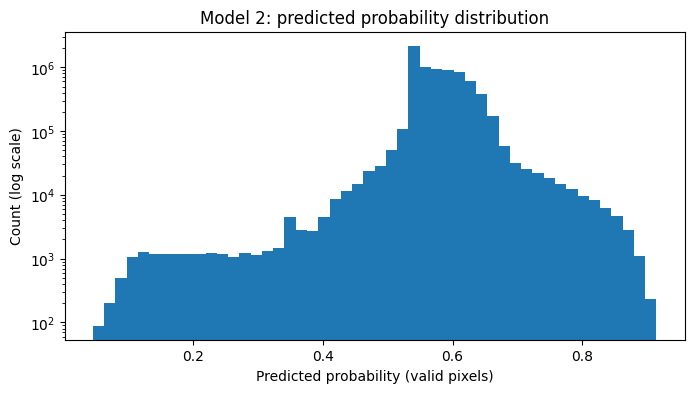

Median predicted prob: 0.5726
Mean predicted prob: 0.5801
% of valid pixels with prob >= 0.5: 98.35%


In [ ]:
# Get a deeper dive into the probability distribution for the valid pixels
plt.figure(figsize=(8,4))
plt.hist(y_score, bins=50)
plt.yscale('log')
plt.xlabel('Predicted probability (valid pixels)')
plt.ylabel('Count (log scale)')
plt.title('Model 2: predicted probability distribution')
plt.show()

print(f"Median predicted prob: {np.median(y_score):.4f}")
print(f"Mean predicted prob: {np.mean(y_score):.4f}")
print(f"% of valid pixels with prob >= 0.5: {(y_score >= 0.5).mean()*100:.2f}%")

Best threshold (max F1): 0.6946
At that threshold — Precision: 0.2265, Recall: 0.3216, F1: 0.2658
IoU at best threshold: 0.1533


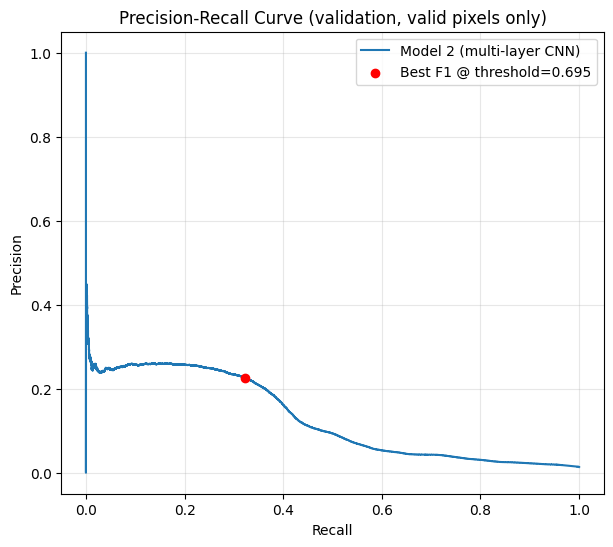

In [ ]:
# Compute full precision-recall curve (uses y_true, y_score already in memory)
precisions, recalls, thresholds = precision_recall_curve(y_true, y_score)

# F1 at each threshold (note: precisions/recalls have one more element than thresholds)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"At that threshold — Precision: {best_precision:.4f}, Recall: {best_recall:.4f}, F1: {best_f1:.4f}")

# IoU at the best threshold, for consistency with our other reported metrics
y_pred_best = (y_score >= best_threshold).astype(int)
iou_best = jaccard_score(y_true, y_pred_best, zero_division=0)
print(f"IoU at best threshold: {iou_best:.4f}")

# Plot the PR curve
plt.figure(figsize=(7,6))
plt.plot(recalls, precisions, label='Model 2 (multi-layer CNN)')
plt.scatter([best_recall], [best_precision], color='red', zorder=5,
            label=f'Best F1 @ threshold={best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (validation, valid pixels only)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Building Model 3 - U-Net CNN

In [16]:
from tensorflow.keras.utils import Sequence
import numpy as np

class ArraySequence(Sequence):
    """Batches directly from existing numpy arrays — no copying, no tf.data shuffle buffer."""
    def __init__(self, X, y, batch_size, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(X))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        return self.X[batch_idx], self.y[batch_idx]

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Build train/val generators
train_gen = ArraySequence(X_train, target_train, batch_size=8, shuffle=True)
val_gen = ArraySequence(X_val, target_val, batch_size=8, shuffle=False)

print(f"Train batches per epoch: {len(train_gen)}")
print(f"Val batches per epoch: {len(val_gen)}")

Train batches per epoch: 1873
Val batches per epoch: 235


In [17]:
def conv_block(x, filters, name_prefix):
    """Two 3x3 conv+ReLU layers, same padding, no bias issues to worry about."""
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', name=f'{name_prefix}_conv1')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', name=f'{name_prefix}_conv2')(x)
    return x

def build_unet(input_shape=(64, 64, 12)):
    inputs = layers.Input(shape=input_shape, name='input')

    # Encoder
    skip1 = conv_block(inputs, 16, 'enc1')          # 64x64x16
    p1 = layers.MaxPooling2D(2, name='pool1')(skip1) # 32x32x16

    skip2 = conv_block(p1, 32, 'enc2')               # 32x32x32
    p2 = layers.MaxPooling2D(2, name='pool2')(skip2)  # 16x16x32

    skip3 = conv_block(p2, 64, 'enc3')               # 16x16x64
    p3 = layers.MaxPooling2D(2, name='pool3')(skip3)  # 8x8x64

    # Bottleneck
    bottleneck = conv_block(p3, 128, 'bottleneck')   # 8x8x128

    # Decoder
    u3 = layers.UpSampling2D(2, interpolation='bilinear', name='up3')(bottleneck)  # 16x16x128
    u3 = layers.Concatenate(name='concat3')([u3, skip3])                          # 16x16x192
    d3 = conv_block(u3, 64, 'dec3')                                               # 16x16x64

    u2 = layers.UpSampling2D(2, interpolation='bilinear', name='up2')(d3)         # 32x32x64
    u2 = layers.Concatenate(name='concat2')([u2, skip2])                         # 32x32x96
    d2 = conv_block(u2, 32, 'dec2')                                              # 32x32x32

    u1 = layers.UpSampling2D(2, interpolation='bilinear', name='up1')(d2)        # 64x64x32
    u1 = layers.Concatenate(name='concat1')([u1, skip1])                        # 64x64x48
    d1 = conv_block(u1, 16, 'dec1')                                             # 64x64x16

    # Output: linear logits, matching masked_weighted_bce's expectation of raw logits
    outputs = layers.Conv2D(1, 1, padding='same', activation=None, name='output')(d1)  # 64x64x1

    model = Model(inputs=inputs, outputs=outputs, name='unet')
    return model

unet_model = build_unet(input_shape=(64, 64, 12))
unet_model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 64, 64,    │          0 │ -                 │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv1 (Conv2D) │ (None, 64, 64,    │      1,744 │ input[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv2 (Conv2D) │ (None, 64, 64,    │      2,320 │ enc1_conv1[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ enc1_conv2[0][0]  │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv1 (Conv2D) │ (None, 32, 32,    │      4,640 │ pool1[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv2 (Conv2D) │ (None, 32, 32,    │      9,248 │ enc2_conv1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 16, 16,    │          0 │ enc2_conv2[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_conv1 (Conv2D) │ (None, 16, 16,    │     18,496 │ pool2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_conv2 (Conv2D) │ (None, 16, 16,    │     36,928 │ enc3_conv1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 8, 8, 64)  │          0 │ enc3_conv2[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_conv1    │ (None, 8, 8, 128) │     73,856 │ pool3[0][0]       │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_conv2    │ (None, 8, 8, 128) │    147,584 │ bottleneck_conv1… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up3 (UpSampling2D)  │ (None, 16, 16,    │          0 │ bottleneck_conv2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat3             │ (None, 16, 16,    │          0 │ up3[0][0],        │
│ (Concatenate)       │ 192)              │            │ enc3_conv2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec3_conv1 (Conv2D) │ (None, 16, 16,    │    110,656 │ concat3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec3_conv2 (Conv2D) │ (None, 16, 16,    │     36,928 │ dec3_conv1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up2 (UpSampling2D)  │ (None, 32, 32,    │          0 │ dec3_conv2[0][0]

 Total params: 488,593 (1.86 MB)

 Trainable params: 488,593 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
import psutil
import gc

gc.collect()
process = psutil.Process()
mem_info = process.memory_info()
print(f"RSS memory in use: {mem_info.rss / 1e9:.2f} GB")
print(f"System available: {psutil.virtual_memory().available / 1e9:.2f} GB")
print(f"System total: {psutil.virtual_memory().total / 1e9:.2f} GB")

RSS memory in use: 5.14 GB
System available: 7.84 GB
System total: 13.61 GB


In [19]:
# Compile the model( same custom loss as before, operating on raw logits)
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=masked_weighted_bce
)

# Checkpoint path
unet_checkpoint_path = '/content/drive/MyDrive/wildfire-prediction-data/unet_best.keras'

checkpoint_cb = ModelCheckpoint(
    filepath=unet_checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [15]:
tf.keras.backend.clear_session()
gc.collect()

# Step 1: does a bare forward pass work at all, on a tiny slice?
print("Testing forward pass on 2 samples...")
tiny_out = unet_model.predict(X_train[:2], verbose=1)
print(f"Forward pass OK, output shape: {tiny_out.shape}")

# Step 2: does a single training step work on a tiny subset?
print("Testing fit() on 16 samples, batch_size=4, 1 epoch...")
unet_model.fit(
    X_train[:16], target_train[:16],
    batch_size=4,
    epochs=1,
    verbose=1
)
print("Tiny fit() OK")

Testing forward pass on 2 samples...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
Forward pass OK, output shape: (2, 64, 64, 1)
Testing fit() on 16 samples, batch_size=4, 1 epoch...
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - loss: 0.3163
Tiny fit() OK


In [20]:
# Train the model
# history_unet = unet_model.fit(
#     X_train, target_train,
#     validation_data=(X_val, target_val),
#     epochs=50,
#     batch_size=4,
#     callbacks=[checkpoint_cb, earlystop_cb],
#     verbose=1
# )

history_unet = unet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

Epoch 1/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - loss: 0.4715
Epoch 1: val_loss improved from None to 0.36876, saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_best.keras
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 682s 361ms/step - loss: 0.3831 - val_loss: 0.3688
Epoch 2/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - loss: 0.3197
Epoch 2: val_loss did not improve from 0.36876
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 686s 366ms/step - loss: 0.3195 - val_loss: 0.3852
Epoch 3/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - loss: 0.3359
Epoch 3: val_loss did not improve from 0.36876
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 681s 364ms/step - loss: 0.3166 - val_loss: 0.3869
Epoch 4/50
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - loss: 0.2667
Epoch 4: val_loss improved from 0.36876 to 0.33164, saving model to /content/drive/MyDrive/wildfire-prediction-data/unet_best.keras

Epoch 4: finished 

In [ ]:
# Verify checkpoint actually landed on disk
unet_checkpoint_path = '/content/drive/MyDrive/wildfire-prediction-data/unet_best.keras'
print(f"Checkpoint exists: {os.path.exists(unet_checkpoint_path)}")
if os.path.exists(unet_checkpoint_path):
    print(f"Checkpoint size: {os.path.getsize(unet_checkpoint_path) / 1e6:.2f} MB")

Checkpoint exists: True
Checkpoint size: 5.98 MB


In [ ]:
# Reconstruct true labels and valid mask from target_val
y_true_full = target_val[..., 0]      # label channel
valid_mask = target_val[..., 1] > 0   # weight channel > 0 means valid pixel

# Get predictions (raw logits -> sigmoid probabilities)
y_pred_logits = unet_model.predict(X_val, verbose=1, batch_size=8)
y_pred_prob = tf.sigmoid(y_pred_logits[..., 0]).numpy()

# Flatten to valid pixels only
y_true = y_true_full[valid_mask]
y_score = y_pred_prob[valid_mask]

# AUC — the primary metric
unet_auc = roc_auc_score(y_true, y_score)
print(f"U-Net Validation AUC: {unet_auc:.4f}")
print(f"Model 2 Validation AUC: 0.8199 (for comparison)")

235/235 ━━━━━━━━━━━━━━━━━━━━ 24s 100ms/step
U-Net Validation AUC: 0.9283
Model 2 Validation AUC: 0.8199 (for comparison)


In [23]:
precisions, recalls, thresholds = precision_recall_curve(y_true, y_score)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision @ best-F1: {precisions[best_idx]:.4f}")
print(f"Recall @ best-F1: {recalls[best_idx]:.4f}")
print(f"F1 @ best-F1: {f1_scores[best_idx]:.4f}")

# IoU at that threshold
y_pred_binary = (y_score >= best_threshold).astype(int)
intersection = np.sum((y_pred_binary == 1) & (y_true == 1))
union = np.sum((y_pred_binary == 1) | (y_true == 1))
iou = intersection / union
print(f"IoU @ best-F1: {iou:.4f}")

Best threshold: 0.7187
Precision @ best-F1: 0.2559
Recall @ best-F1: 0.4792
F1 @ best-F1: 0.3337
IoU @ best-F1: 0.2002
